
This code is for demonstration of Dynamiqs package by Alice and Bob. We will Simulate the relaxation dynamics of cavity (storage), the transmon qubit, resonator (readout) - qubit coupled system, and all three coupled together. 

In [1]:

import dynamiqs as dq
import jax.numpy as jnp
from pathlib import Path
import json
import matplotlib.pyplot as plt


param_path = Path("../params.json")
with open(param_path, "r") as f:
    params = json.load(f)

# Define the truncation of each mode
N_cavity = 15
N_qubit = 2
N_resonator = 4

# Define Dynamics related parameters
tmax = 1/params["cavity_decay"]
td = 5000

__1.a The Cavity Relaxation (Undriven and driven)__\
    We will start with the case of an undriven cavity relaxation. The cavity can be initialized in fock 2,3 etc states or Coherent states and then it will be allowed to relax under the anhilation operator as dissipator. The equation of motion reads
    $$ \frac{d\rho}{dt} = -i [H,\rho] + \kappa_a \mathcal{L}(a) \rho, ~~~\text{with}~ H = \Omega a^{\dagger}a + \chi_{aa} a^{\dagger}a^{\dagger } a a  $$ 
    where $\Omega$ is the frequency, $\chi_aa$ being the self-kerr and $\kappa_a$ is the dissipation rate.

|██████████| 100.0% ◆ elapsed 7.78ms ◆ remaining 0.00ms


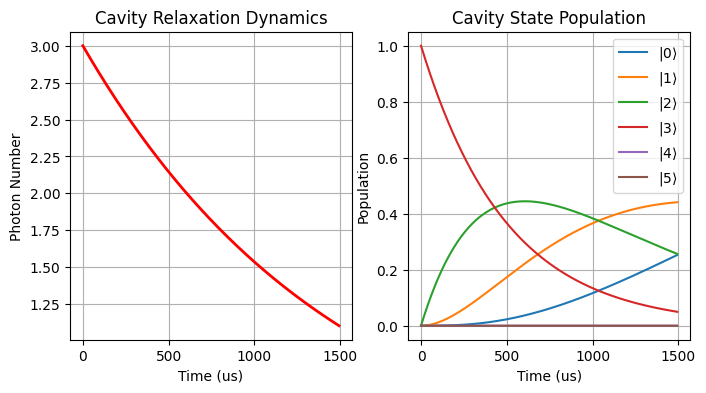

==== MESolveResult ====
Method  : Tsit5
Infos   : 17 steps (17 accepted, 0 rejected)
States  : QArray complex64 (5000, 15, 15) | 8.6 Mb
Expects : Array complex64 (1, 5000) | 39.1 Kb
1.1036383 0.0


In [2]:
# Define the system
rho0 = dq.fock_dm(N_cavity,3)
driven_cavity = False

# Define the Hamiltonian, Dissipators and observables
a = dq.destroy(N_cavity)
H = params["cavity_detuning"]*a.dag() @ a + params["cavity_self_kerr"]*a.dag() @ a.dag() @ a @ a
if driven_cavity:
    H_drive = params["cavity_drive_amp"]*(a + a.dag())
    H = H + H_drive


Dissipator_a = [jnp.sqrt(params["cavity_decay"])*a]
Observable_a = [a.dag() @ a]

# Define the Scope of the simulation
tsave = jnp.linspace(0.0, tmax, td) 
method = dq.method.Tsit5(rtol=1e-6, atol=1e-8)

# Run the simulation
result = dq.mesolve(H, Dissipator_a, rho0, tsave=tsave, exp_ops=Observable_a,method=method)  

# Analyzing the results
states_array = [rho.to_jax() for rho in result.states]
Populattion_cavity = jnp.array([jnp.diag(rho).real for rho in states_array])

fig, ax = plt.subplots(1, 2, figsize=(8,4))
ax[0].plot(tsave, result.expects[0].real, linewidth=2, color = "r")
ax[0].set_xlabel("Time (us)")
ax[0].set_ylabel("Photon Number")
ax[0].set_title("Cavity Relaxation Dynamics")
ax[0].grid()

for n in range(6):
    ax[1].plot(tsave, Populattion_cavity[:,n], label=rf"$\vert {n} \rangle$")
ax[1].set_xlabel("Time (us)")
ax[1].set_ylabel("Population")
ax[1].set_title("Cavity State Population")
ax[1].legend()
ax[1].grid()
plt.show()

print(result)
A = result.expects[0].real
B = abs(params["cavity_drive_amp"]/(params["cavity_detuning"] + params["cavity_decay"]*1j/2))
print(A[-1], B**2)